# Análisis Estadístico Básico con Scipy y Statsmodels

Este cuaderno está diseñado para practicar análisis estadístico básico sobre un conjunto de datos de películas (`movies.csv`).

**Objetivos:**
- Calcular estadísticas descriptivas con Pandas y Scipy.
- Realizar pruebas de hipótesis con `scipy.stats`.
- Explorar modelos de regresión lineal con `statsmodels`.

Asegúrate de tener instaladas las bibliotecas necesarias:
```bash
pip install scipy statsmodels seaborn
```

In [8]:
# Cargar bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Cargar dataset
# Asegúrate de tener el archivo 'movies.csv' en la misma carpeta
df = pd.read_csv("movies_limpio.csv")
df.head(3)

,Rank,Title,Year,Score,Metascore,Genre,Vote,Director,Runtime,Revenue,Description,Runtime_horas,GeneroPrincipal,Decada
0,1,The Shawshank Redemption,1994,9.3,80.0,Drama,2011509,Frank Darabont,142,28.34,Two imprisoned men bond over a number of years...,2.366667,Drama,1990
1,2,The Dark Knight,2008,9.0,84.0,"Action, Crime, Drama",1980200,Christopher Nolan,152,534.86,When the menace known as the Joker emerges fro...,2.533333,Action,2000
2,3,Inception,2010,8.8,74.0,"Action, Adventure, Sci-Fi",1760209,Christopher Nolan,148,292.58,A thief who steals corporate secrets through t...,2.466667,Action,2010


## 1. Estadísticas Descriptivas
### 1.1 Con Pandas

In [9]:
df.columns

Index(['Rank', 'Title', 'Year', 'Score', 'Metascore', 'Genre', 'Vote',
       'Director', 'Runtime', 'Revenue', 'Description', 'Runtime_horas',
       'GeneroPrincipal', 'Decada'],
      dtype='object')

In [10]:
df.shape

(7473, 14)

In [11]:
# Estadísticas generales
df.describe()

,Rank,Year,Score,Metascore,Vote,Runtime,Revenue,Runtime_horas,Decada
count,7473.000000,7473.000000,7473.00000,6125.000000,7.473000e+03,7473.000000,7473.000000,7473.000000,7473.000000
mean,4310.458584,2000.225880,6.57879,56.702531,8.051643e+04,109.240867,36.263402,1.820681,1995.680450
std,2783.273271,14.704753,0.98831,17.873832,1.402570e+05,20.407461,60.882025,0.340124,14.874407
min,1.000000,1915.000000,1.50000,10.000000,6.022000e+03,45.000000,0.000000,0.750000,1910.000000
25%,1912.000000,1994.000000,6.00000,44.000000,1.306100e+04,95.000000,1.890000,1.583333,1990.000000
50%,3992.000000,2004.000000,6.70000,57.000000,3.153300e+04,105.000000,15.090000,1.750000,2000.000000
75%,6534.000000,2011.000000,7.30000,70.000000,8.441200e+04,119.000000,43.860000,1.983333,2010.000000
max,9996.000000,2018.000000,9.30000,99.000000,2.011509e+06,366.000000,936.660000,6.100000,2010.000000


### 1.2 Agrupaciones por Década o Género

In [12]:
# Media de duración por década
df.groupby("Decada")["Runtime_horas"].mean()

Decada
1910    2.983333
1920    1.556863
1930    1.720968
1940    1.801701
1950    1.985348
1960    2.112384
1970    1.902664
1980    1.788150
1990    1.808218
2000    1.802105
2010    1.830011
Name: Runtime_horas, dtype: float64

### 1.3 Con Scipy: Describe, Skew, Kurtosis

In [13]:
# Estadísticas usando scipy
stats.describe(df["Score"].dropna())    #scipy.stats = stats

DescribeResult(nobs=7473, minmax=(1.5, 9.3), mean=6.578790311789108, variance=0.9767569947026997, skewness=-0.7740626845462865, kurtosis=1.3357324416613352)

In [14]:
stats.describe(df["Revenue"].dropna())

DescribeResult(nobs=7473, minmax=(0.0, 936.66), mean=36.263401579017795, variance=3706.6209748035144, skewness=4.203600807165276, kurtosis=28.676128476984502)

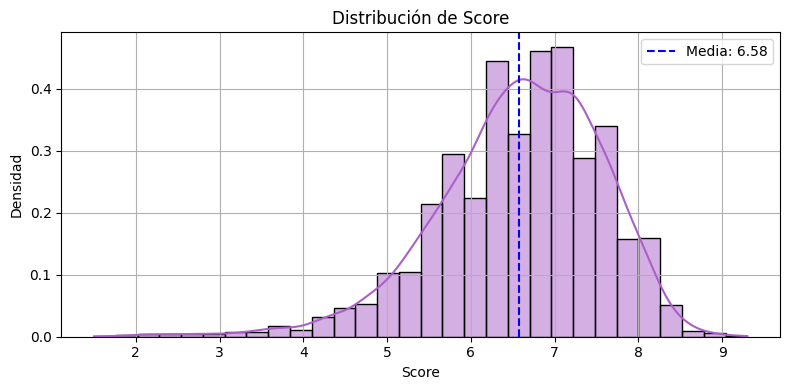

In [ ]:
# Para esta simulación, creamos una serie de "Score" similar al comportamiento anterior
score = df["Score"].dropna()

# Graficar directamente la variable Score como histograma con densidad
plt.figure(figsize=(8, 4))
sns.histplot(score, kde=True, bins=30, color='#AA60C8', stat='density')
plt.title("Distribución de Score")
plt.xlabel("Score")
plt.ylabel("Densidad")
plt.axvline(score.mean(), color='blue', linestyle='--', label=f'Media: {score.mean():.2f}') # La línea de la media
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


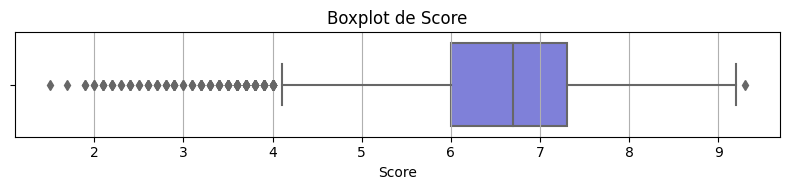

In [18]:
# Crear boxplot de la variable Score
plt.figure(figsize=(8, 2))
sns.boxplot(x=score, color='#7071E8')
plt.title("Boxplot de Score")
plt.xlabel("Score")
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


Tenemos 7473 puntuaciones de películas. El puntaje promedio es de 6.57. La varianza no es muy alta, lo que indica que los scores no se dispersan demasiado. Lo interesante es que la asimetría negativa nos dice que hay una tendencia a que las películas tengan puntuaciones altas, pero también existen algunas pocas con puntuaciones muy bajas (de ahí la cola izquierda más larga). La curtosis mayor a 0 sugiere que la distribución tiene colas pesadas, es decir, hay varias películas con puntajes extremos —tanto muy altos como muy bajos— que se alejan del promedio.

**Ejercicio**
Elijan una variable numérica distinta a Score para repetir el análisis. Si no están seguros cuál elegir, pueden trabajar con Duration o Year. Luego compararemos resultados.

In [ ]:
# Código del ejercicio

## 2. Pruebas de Hipótesis
### Comparar duración entre géneros

In [19]:
# Conteo por género
conteo_generos = df["GeneroPrincipal"].value_counts()
conteo_generos

GeneroPrincipal
Comedy       2165
Action       1568
Drama        1506
Crime         552
Adventure     433
Biography     429
Horror        340
Animation     338
Mystery        40
Fantasy        37
Thriller       13
Romance        12
Sci-Fi         12
Western        12
Family         10
Musical         2
FilmNoir        2
Music           1
War             1
Name: count, dtype: int64

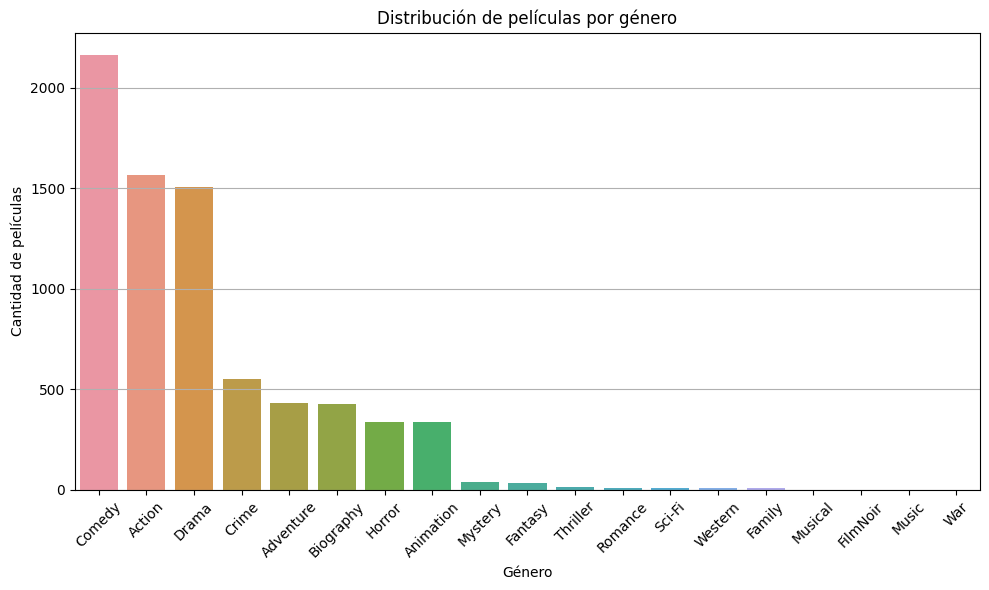

In [27]:
sns.color_palette("tab10")

# Gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=conteo_generos.index, y=conteo_generos.values)
plt.title("Distribución de películas por género")
plt.ylabel("Cantidad de películas")
plt.xlabel("Género")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Selección de dos géneros
accion = df[df["GeneroPrincipal"] == "Action"]["Runtime_horas"].dropna()
drama = df[df["GeneroPrincipal"] == "Drama"]["Runtime_horas"].dropna()

# Prueba t de muestras independientes
stats.ttest_ind(accion, drama, equal_var=False) #Grupo1=accion y Grupo2=drama

TtestResult(statistic=-2.488813460354308, pvalue=0.012870734451653673, df=3006.4260331290056)

T-test versión de Welch, que no asume igualdad de varianzas y es más robusta.

**Ejercicio**
Elijan dos géneros distintos de películas (que no sean “Action” ni “Drama”).
    Comparen la duración promedio entre esos dos géneros usando scipy.stats.ttest_ind.

    Respondan:
        ¿Cuál es el valor p?
        ¿Rechazan la hipótesis nula con un nivel de significancia del 5%?
        ¿Qué género parece tener películas más largas en promedio entre los dos elegidos?

## 3. Regresión Lineal con Statsmodels

**¿Qué es statsmodels?**

statsmodels es una biblioteca de Python para realizar análisis estadísticos más formales y detallados que los que ofrece scipy o pandas por sí solos.

Permite hacer:
- Modelos de regresión lineal y logística
- ANOVA
- Series de tiempo
- Pruebas estadísticas clásicas
- Modelos econométricos

**¿Qué es OLS?**

OLS significa "Ordinary Least Squares" o Mínimos Cuadrados Ordinarios.
Es el método más común para hacer regresión lineal, que consiste en encontrar la recta que mejor se ajusta a los datos minimizando la suma de los errores al cuadrado.

La regresión lineal busca modelar la relación entre una variable dependiente (Y, como Score) y una o más variables independientes (X, como Runtime, Year, etc.).

$$Y = β0 + β1X1 + β2X2 + ... + ε$$

Ejemplo:
$$Score = β0 + β1 * Runtime\_horas + error$$

Donde:
- $β0$ es la intersección (valor de Score cuando Runtime_horas = 0)
- $β1$ es el efecto estimado de una hora extra en duración sobre el score


In [29]:
# Regresión Score ~ Runtime
modelo = smf.ols('Score ~ Runtime_horas', data=df).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     1044.
Date:                Fri, 11 Apr 2025   Prob (F-statistic):          1.67e-214
Time:                        11:34:24   Log-Likelihood:                -10027.
No. Observations:                7473   AIC:                         2.006e+04
Df Residuals:                    7471   BIC:                         2.007e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         4.7263      0.058     81.036

In [36]:
df.describe()

,Rank,Year,Score,Metascore,Vote,Runtime,Revenue,Runtime_horas,Decada,Score_pred
count,7473.000000,7473.000000,7473.00000,6125.000000,7.473000e+03,7473.000000,7473.000000,7473.000000,7473.000000,7473.000000
mean,4310.458584,2000.225880,6.57879,56.702531,8.051643e+04,109.240867,36.263402,1.820681,1995.680450,6.578790
std,2783.273271,14.704753,0.98831,17.873832,1.402570e+05,20.407461,60.882025,0.340124,14.874407,0.399582
min,1.000000,1915.000000,1.50000,10.000000,6.022000e+03,45.000000,0.000000,0.750000,1910.000000,5.649038
25%,1912.000000,1994.000000,6.00000,44.000000,1.306100e+04,95.000000,1.890000,1.583333,1990.000000,6.306626
50%,3992.000000,2004.000000,6.70000,57.000000,3.153300e+04,105.000000,15.090000,1.750000,2000.000000,6.508355
75%,6534.000000,2011.000000,7.30000,70.000000,8.441200e+04,119.000000,43.860000,1.983333,2010.000000,6.765304
max,9996.000000,2018.000000,9.30000,99.000000,2.011509e+06,366.000000,936.660000,6.100000,2010.000000,10.788187


In [ ]:
# Regresión Score ~ Runtime
modelo = smf.ols('Score ~ Runtime_horas', data=df).fit()
print(modelo.summary())

Interpretación de los coeficientes

|Término|	Valor|	Interpretación|
|----|----|----|
|Intercepto|	4.7263|	Es el valor esperado de Score si Runtime_horas fuera 0 (solo interpretativo).|
|Runtime_horas|	1.0174|	Por cada hora extra de duración, se espera que el Score aumente en 1.017 puntos, en promedio.|

--

|Métrica|	Valor|	Interpretación|
|----|----|----|
|R²|	0.123|	Solo el 12.3% de la variación en Score se explica por Runtime_horas.|
|F-statistic|	1044|	El modelo es globalmente significativo.|
|Prob (F-statistic)|	1.67e-214|	Hay una alta evidencia estadística de que el modelo tiene poder explicativo.|

--

|Métrica|	Valor|	Interpretación|
|-----|----|----|
|Skew/Kurtosis|	-0.77 / 4.63|	Indican asimetría negativa y colas pesadas.|
|Durbin-Watson|	1.83|	No hay evidencia fuerte de autocorrelación de errores.|
|Omnibus/JB test|	p ≈ 0|	La distribución de los residuos no es perfectamente normal.|

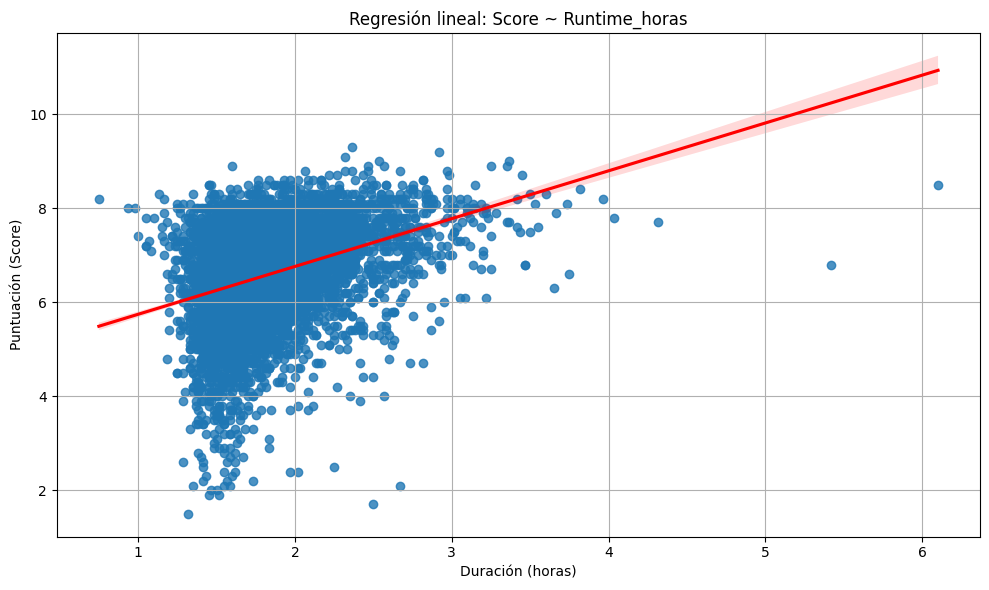

In [30]:
# Grafica de la regresión
plt.figure(figsize=(10, 6))
sns.regplot(x="Runtime_horas", y="Score", data=df, line_kws={"color": "red"})
plt.title("Regresión lineal: Score ~ Runtime_horas")
plt.xlabel("Duración (horas)")
plt.ylabel("Puntuación (Score)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
# Regresión Score ~ Duration + Year
modelo2 = smf.ols('Score ~ Runtime_horas + Year', data=df).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     729.8
Date:                Fri, 11 Apr 2025   Prob (F-statistic):          3.01e-290
Time:                        11:40:27   Log-Likelihood:                -9848.4
No. Observations:                7473   AIC:                         1.970e+04
Df Residuals:                    7470   BIC:                         1.972e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        31.9706      1.427     22.397

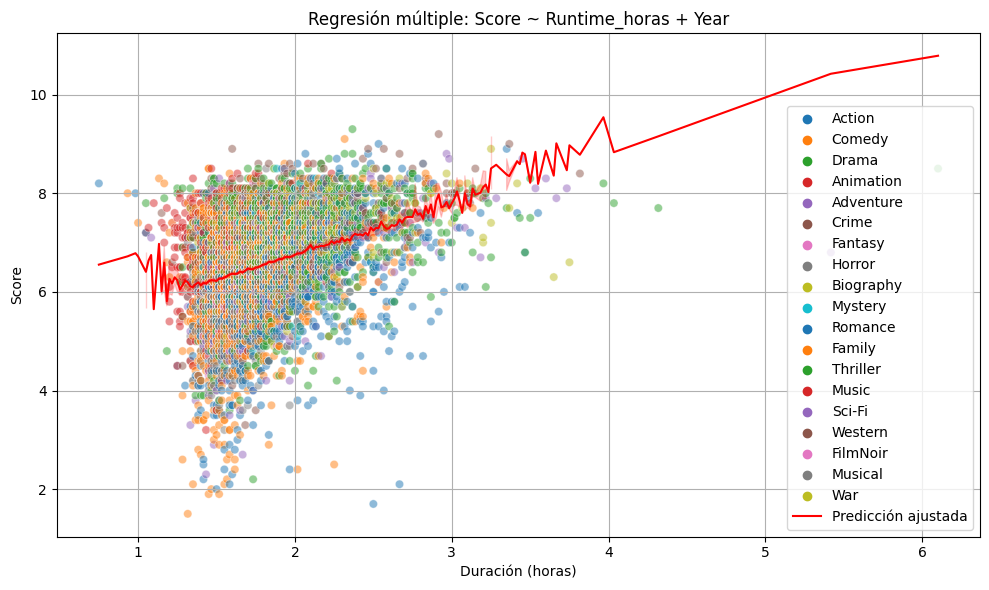

In [35]:
# Agregar columnas de predicción al DataFrame
#df["Year"] = modelo2.model.data.frame["Year"]
df["Score_pred"] = modelo2.fittedvalues

# Ordenar DataFrame por Runtime_horas para graficar línea
df_ordenado = df.sort_values("Runtime_horas")

df_ordenado["Score_pred_smooth"] = df_ordenado["Score_pred"].rolling(50).mean()

# Graficar
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ordenado, x="Runtime_horas", y="Score", hue="GeneroPrincipal", palette="tab10", alpha=0.5)
sns.lineplot(data=df_ordenado, x="Runtime_horas", y="Score_pred", color="red", label="Predicción ajustada")
plt.title("Regresión múltiple: Score ~ Runtime_horas + Year")

plt.xlabel("Duración (horas)")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


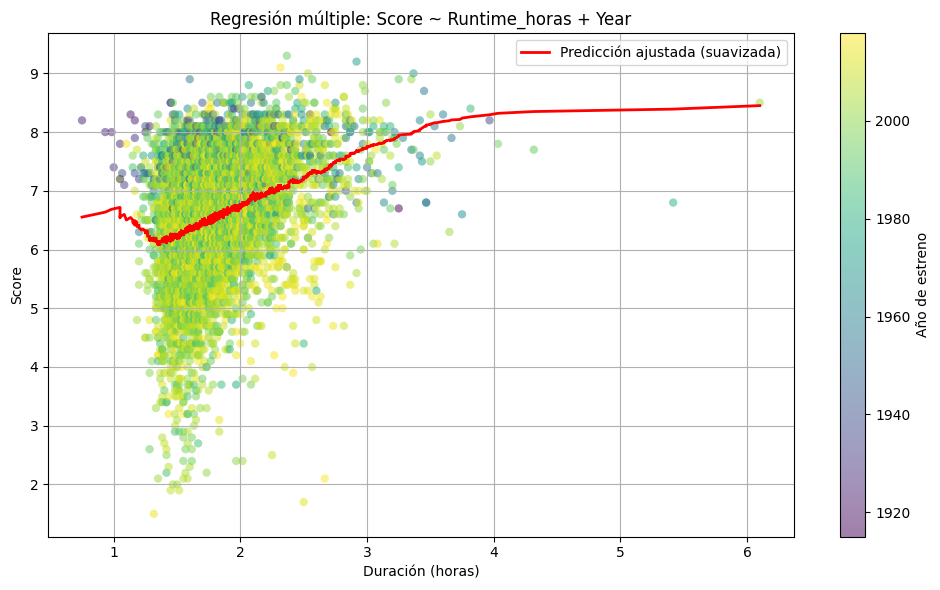

In [ ]:
#Solo con marplotlib
# Ordenar y suavizar para una mejor línea
df_ordenado = df.sort_values("Runtime_horas")
df_ordenado["Score_pred_smooth"] = df_ordenado["Score_pred"].rolling(window=50, min_periods=1).mean()

# Crear la gráfica
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_ordenado["Runtime_horas"], df_ordenado["Score"],
    c=df_ordenado["Year"], cmap="viridis", alpha=0.5, edgecolor='none'
)
plt.plot(
    df_ordenado["Runtime_horas"], df_ordenado["Score_pred_smooth"],
    color="red", linewidth=2, label="Predicción ajustada (suavizada)"
)
plt.title("Regresión múltiple: Score ~ Runtime_horas + Year")
plt.xlabel("Duración (horas)")
plt.ylabel("Score")
plt.colorbar(scatter, label="Año de estreno")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Actividad Final
- Elige dos géneros y compara su duración con `ttest_ind`.
- Realiza una regresión lineal para predecir `Score` usando al menos dos variables independientes.
- ¿Qué concluyes de los resultados?